# Task 2: Credit Risk Prediction

This task aims to predict whether a loan will be approved using machine learning techniques.

In [10]:
import pandas as pd

df = pd.read_csv("loan_prediction_dataset.csv")
df.head()

,Age,Income,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Loan_Approved
0,56,81788,334,15022,48,Employed,0
1,69,102879,781,21013,24,Self-Employed,1
2,46,58827,779,39687,60,Self-Employed,0
3,32,127188,364,16886,24,Unemployed,0
4,60,25655,307,26256,36,Unemployed,0


In [11]:
df.isnull().sum()

Age                  0
Income               0
Credit_Score         0
Loan_Amount          0
Loan_Term            0
Employment_Status    0
Loan_Approved        0
dtype: int64

## Missing Values

We check for missing values in the dataset before applying machine learning.

In [13]:
df.ffill(inplace=True)

## Data Cleaning

Missing values were handled using forward fill method.

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Employment_Status'] = le.fit_transform(df['Employment_Status'])

## Data Encoding

Categorical column Employment_Status was converted into numerical values.

In [15]:
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## Data Splitting

The dataset is divided into training and testing sets.

In [17]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Model Training

Logistic Regression model is used for classification.

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8325
Confusion Matrix:
 [[305  22]
 [ 45  28]]


<Axes: xlabel='Loan_Approved', ylabel='count'>

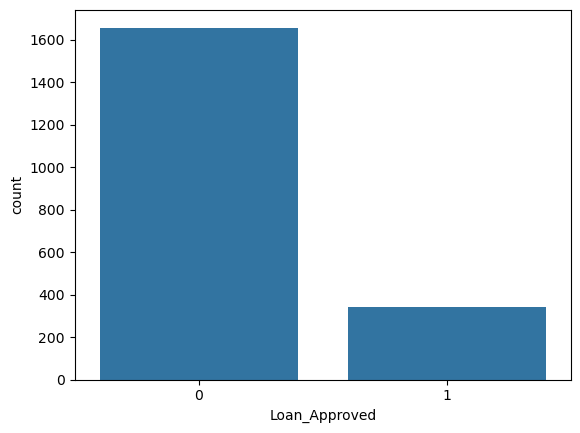

In [20]:
import seaborn as sns
sns.countplot(x='Loan_Approved', data=df)

This shows distribution of approved vs rejected loans.

## Conclusion

- Data was cleaned and categorical values were encoded.
- Logistic Regression model was trained on the dataset.
- The model performance was evaluated using accuracy and confusion matrix.